# Task 3: Customer Churn Prediction (Bank Customers)

## Introduction
Customer churn means a customer leaves a company or stops using its services. In this task, we use a bank customer dataset to predict whether a customer is likely to leave the bank.

## Problem Statement
The goal is to clean and prepare the dataset, encode categorical features such as Geography and Gender, train a classification model, and analyze feature importance to understand what factors influence customer churn.


## 1. Import Required Libraries

In [1]:
# Basic data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Display plots clearly
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


## 2. Load the Dataset

We load the Churn Modelling dataset directly from an online CSV source. This works easily in Google Colab.


In [2]:
# Dataset URL
url = "https://raw.githubusercontent.com/selva86/datasets/master/Churn_Modelling.csv"

# Load dataset
df = pd.read_csv(url)

# Show first five rows
df.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 3. Dataset Understanding

Now we check the structure of the dataset using shape, columns, and basic information.


In [3]:
# Number of rows and columns
print("Dataset shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Dataset information
print("\nDataset info:")
df.info()


Dataset shape: (10000, 14)

Columns:
Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMemb

In [4]:
# Summary statistics for numerical columns
df.describe()


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## 4. Check Missing Values

Before training the model, we check if there are any missing values.


In [5]:
# Check missing values in each column
df.isnull().sum()


,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


## 5. Data Cleaning and Preparation

Some columns are identifiers and are not useful for prediction. We remove them.

Columns removed:
- RowNumber
- CustomerId
- Surname

The target column is `Exited`, where:
- 0 means customer did not leave
- 1 means customer left the bank


In [6]:
# Drop unnecessary identifier columns
df_clean = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

# Show cleaned dataset
df_clean.head()


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 6. Exploratory Data Analysis (EDA)

Now we visualize important features to understand customer churn patterns.


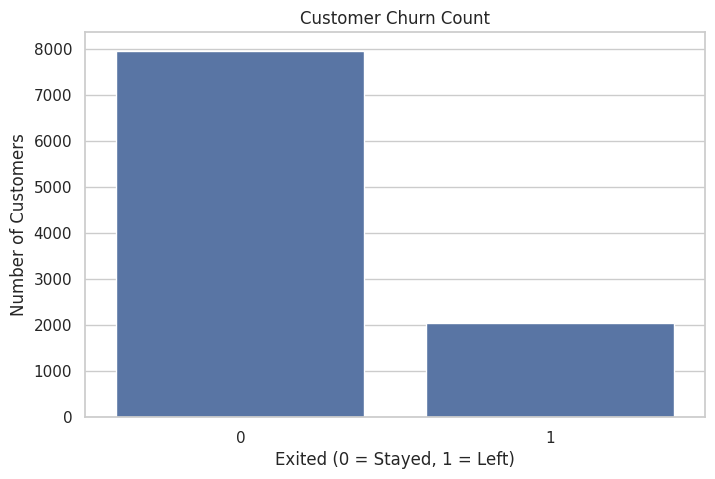

In [7]:
# Count of customers who stayed vs exited
plt.figure()
sns.countplot(data=df_clean, x="Exited")
plt.title("Customer Churn Count")
plt.xlabel("Exited (0 = Stayed, 1 = Left)")
plt.ylabel("Number of Customers")
plt.show()


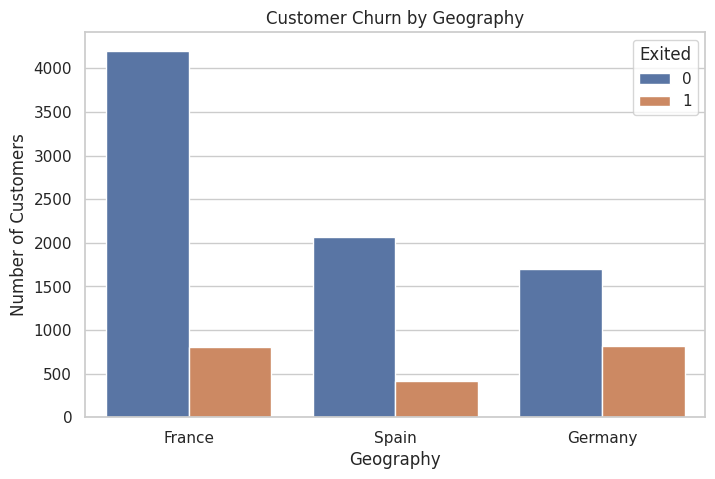

In [8]:
# Churn by Geography
plt.figure()
sns.countplot(data=df_clean, x="Geography", hue="Exited")
plt.title("Customer Churn by Geography")
plt.xlabel("Geography")
plt.ylabel("Number of Customers")
plt.legend(title="Exited")
plt.show()


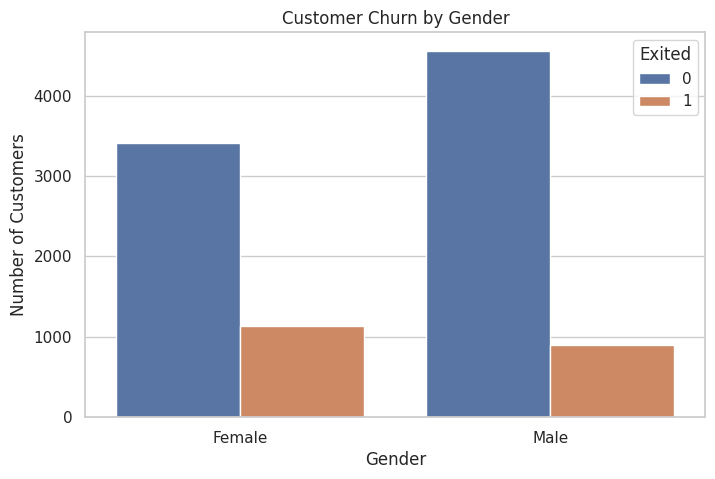

In [9]:
# Churn by Gender
plt.figure()
sns.countplot(data=df_clean, x="Gender", hue="Exited")
plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.legend(title="Exited")
plt.show()


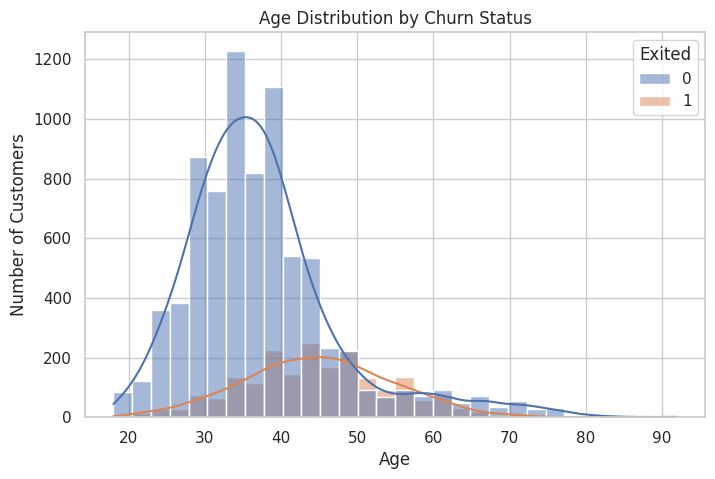

In [10]:
# Age distribution by churn status
plt.figure()
sns.histplot(data=df_clean, x="Age", hue="Exited", kde=True, bins=30)
plt.title("Age Distribution by Churn Status")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()


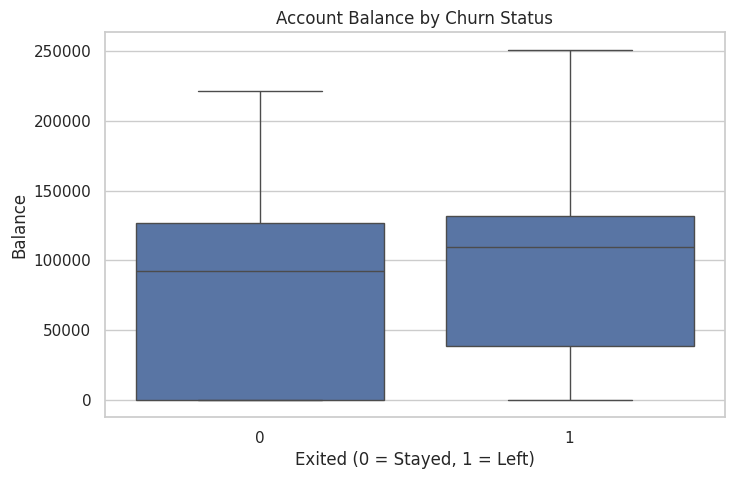

In [11]:
# Balance vs churn
plt.figure()
sns.boxplot(data=df_clean, x="Exited", y="Balance")
plt.title("Account Balance by Churn Status")
plt.xlabel("Exited (0 = Stayed, 1 = Left)")
plt.ylabel("Balance")
plt.show()


## 7. Encode Categorical Features

Machine learning models cannot directly understand text values. So we convert categorical columns into numeric form.

Here:
- Geography is converted into numeric labels
- Gender is converted into numeric labels


In [12]:
# Create label encoders
le_geography = LabelEncoder()
le_gender = LabelEncoder()

# Apply encoding
df_clean["Geography"] = le_geography.fit_transform(df_clean["Geography"])
df_clean["Gender"] = le_gender.fit_transform(df_clean["Gender"])

# Show encoded data
df_clean.head()


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


## 8. Split Features and Target

We separate the input features and target output.


In [13]:
# Features
X = df_clean.drop("Exited", axis=1)

# Target
y = df_clean["Exited"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)


Feature shape: (10000, 10)
Target shape: (10000,)


## 9. Train-Test Split

We divide the dataset into training and testing data.

- 80% data is used for training
- 20% data is used for testing


In [14]:
# Split data into training and testing parts
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


Training data shape: (8000, 10)
Testing data shape: (2000, 10)


## 10. Train Classification Model

We use a Decision Tree Classifier for customer churn prediction.


In [15]:
# Create model
model = DecisionTreeClassifier(random_state=42, max_depth=5)

# Train model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)


## 11. Model Evaluation

We evaluate the model using:
- Accuracy
- Confusion Matrix
- Classification Report


In [16]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", round(accuracy * 100, 2), "%")


Model Accuracy: 85.4 %


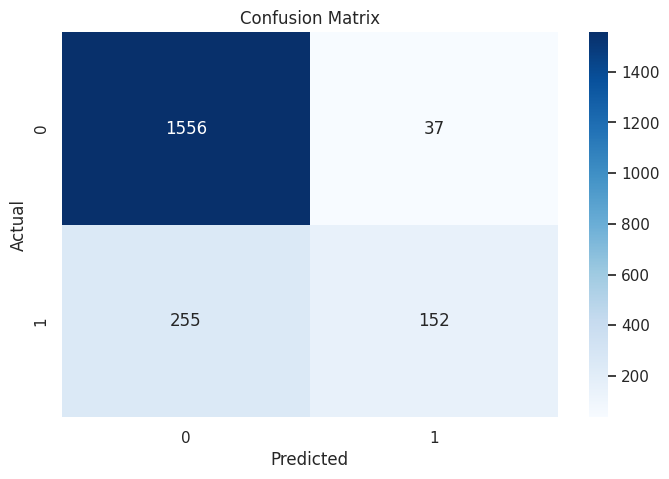

Confusion Matrix:
[[1556   37]
 [ 255  152]]


In [17]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Confusion Matrix:")
print(cm)


In [18]:
# Classification report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.86      0.98      0.91      1593
           1       0.80      0.37      0.51       407

    accuracy                           0.85      2000
   macro avg       0.83      0.68      0.71      2000
weighted avg       0.85      0.85      0.83      2000



## 12. Feature Importance

Feature importance helps us understand which features are more influential in predicting customer churn.


In [19]:
# Get feature importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

# Sort by importance
importance = importance.sort_values(by="Importance", ascending=False)

importance


,Feature,Importance
3,Age,0.457231
6,NumOfProducts,0.335302
8,IsActiveMember,0.143293
5,Balance,0.030685
1,Geography,0.018385
9,EstimatedSalary,0.009836
0,CreditScore,0.004219
4,Tenure,0.001050
2,Gender,0.000000
7,HasCrCard,0.000000


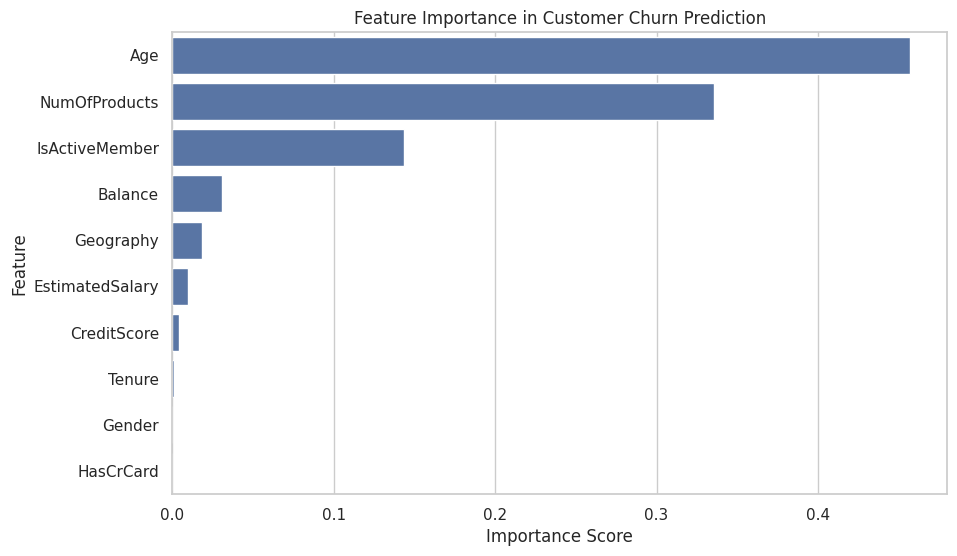

In [20]:
# Visualize feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=importance, x="Importance", y="Feature")
plt.title("Feature Importance in Customer Churn Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()


## 13. Conclusion

In this task, we predicted customer churn using a bank customer dataset. We cleaned the data, encoded categorical features, trained a Decision Tree classification model, and evaluated the model using accuracy and a confusion matrix.

The feature importance graph helps identify which customer details influence churn more strongly. Usually, features such as age, number of products, balance, and activity status can play an important role in predicting whether a customer may leave the bank.

This task helped us understand categorical encoding, classification modeling, model evaluation, and feature importance analysis.
